# Task 4 — The Transformer Architecture

### 1. The Full Encoder-Decoder Stack
The **Transformer** completely discards recurrent connections, relying entirely on self-attention mechanisms to map inputs to outputs.

Below is the official architectural diagram of the Transformer from the original paper *"Attention Is All You Need"*:

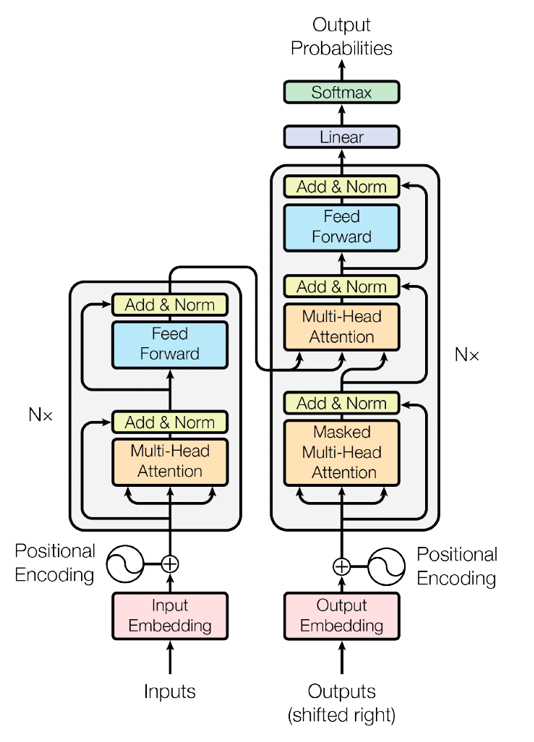

Here is the simplified flow of the stacks side-by-side:

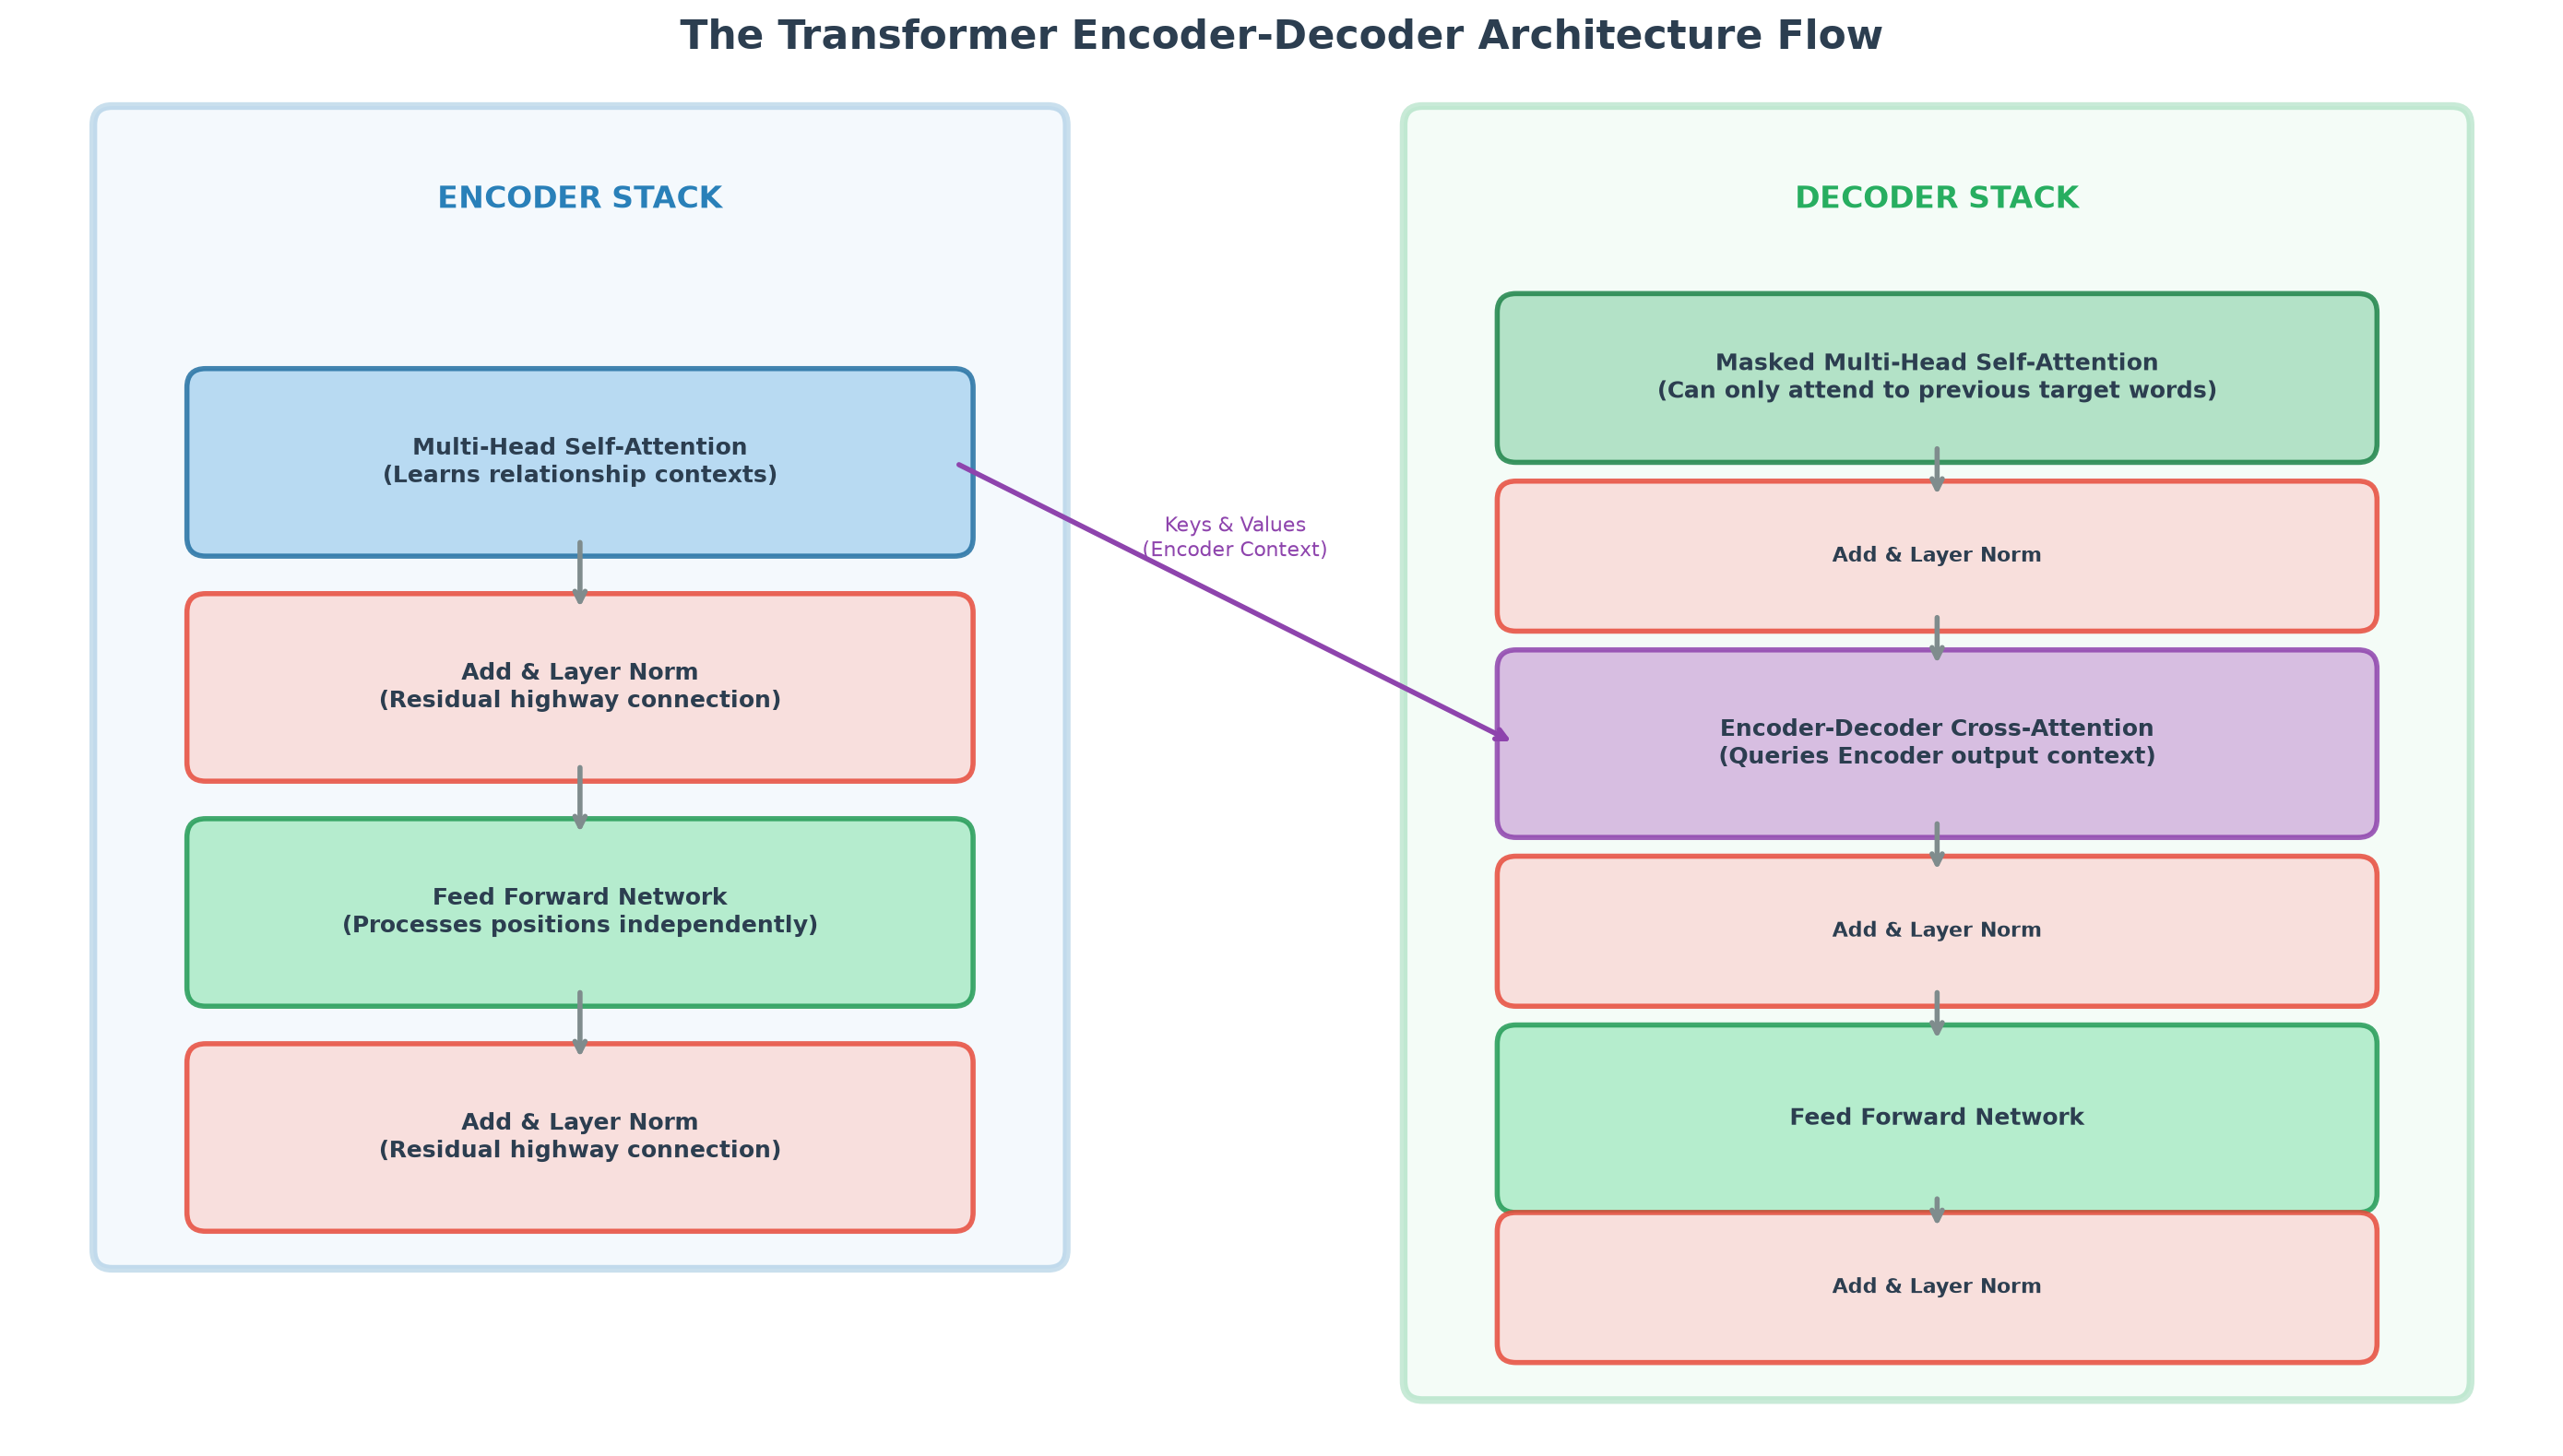

---

### 2. Detailed Sub-layers Breakdown
Within the Transformer block, we discard standard sequence loops. Instead, processing is done by stacking layers of attention and feed-forward networks, wrapped in skip connections and layer normalization. Let's look at each sub-layer conceptually:

#### A. Sub-layers of the Encoder Block

1. **Multi-Head Self-Attention**:
   - **Concept**: This sub-layer allows the model to associate each word in the input sentence with all other words. For example, in the sentence "The animal didn't cross the street because **it** was too tired", the self-attention layer allows the representation of "it" to strongly associate with "animal".
   - **Multi-Head Logic**: Instead of running a single attention pass, the query ($Q$), key ($K$), and value ($V$) vectors are projected into multiple subspaces (heads). Each head runs self-attention in parallel, allowing the model to focus on different types of relations (e.g., one head handles syntax/agreement, while another resolves semantic reference).
   
2. **Position-wise Feed-Forward Network (FFN)**:
   - **Concept**: After attention combines contextual information from all words, the resulting vectors are passed through a Feed-Forward Network. This consists of two linear transformations with a ReLU activation in between.
   - **Position-wise**: The exact same linear transformations are applied to the vector at *each word position independently and identically*. Think of it as a small, specialized fully-connected network that processes the features of each token separately, after attention has completed the group discussion.

#### B. Sub-layers of the Decoder Block

1. **Masked Multi-Head Self-Attention**:
   - **Concept**: Just like the encoder's self-attention, this layer allows target words to attend to other target words. However, during generation (inference), the decoder produces words autoregressively (one-by-one). 
   - **Masking**: To train the decoder in parallel on the entire target sentence without letting it cheat, we apply a causal mask. This mask blocks attention to future positions by replacing their dot-product similarity scores with negative infinity ($-\infty$) before passing them to the Softmax function. This ensures that when predicting the word at step $t$, the decoder can only look at words from step $1$ to $t-1$.
   
2. **Encoder-Decoder Cross-Attention**:
   - **Concept**: This is the structural bridge between the Encoder and Decoder stacks. Here, the Query ($Q$) vector is created from the previous decoder sub-layer's outputs, while the Keys ($K$) and Values ($V$) vectors are fetched directly from the output of the Encoder stack.
   - **Lookup**: This allows every decoder position to query the entire encoder representation, pulling relevant context from the source sentence (like looking at the textbook during translation) before outputting the final translated token.
   
3. **Position-wise Feed-Forward Network (FFN)**:
   - **Concept**: Similar to the encoder's FFN, this sub-layer applies a non-linear two-layer projection to refine the decoded hidden representation at each position separately.

#### C. Residual Connections & Layer Normalization (Add & Norm)

Every sub-layer in both the Encoder and Decoder is wrapped in a residual skip connection followed by a Layer Normalization step:
$$\text{Output} = \text{LayerNorm}(x + \text{SubLayer}(x))$$

1. **Residual Connections (Add)**:
   - **Concept**: By adding the input $x$ of a sub-layer directly to its output, we create an "information highway". During backpropagation, gradients can flow back to early layers without undergoing matrix multiplication decay. This is the main reason we can train Transformers that are hundreds of layers deep without the gradients vanishing.
   
2. **Layer Normalization (Norm)**:
   - **Concept**: Layer normalization stabilizes training by normalizing the activation values *across all features for a single token position* (mean of 0, variance of 1) and then applying a learnable scale and shift parameter. This keeps activation values within a stable range, preventing inputs to subsequent layers from shifting scale during training.

---

### 3. Multi-Head Attention: Parallel Learning Heads
Rather than calculating a single attention weight mapping, the Transformer splits the Queries, Keys, and Values into $h$ separate chunks and projects them in parallel. This is called **Multi-Head Attention**.

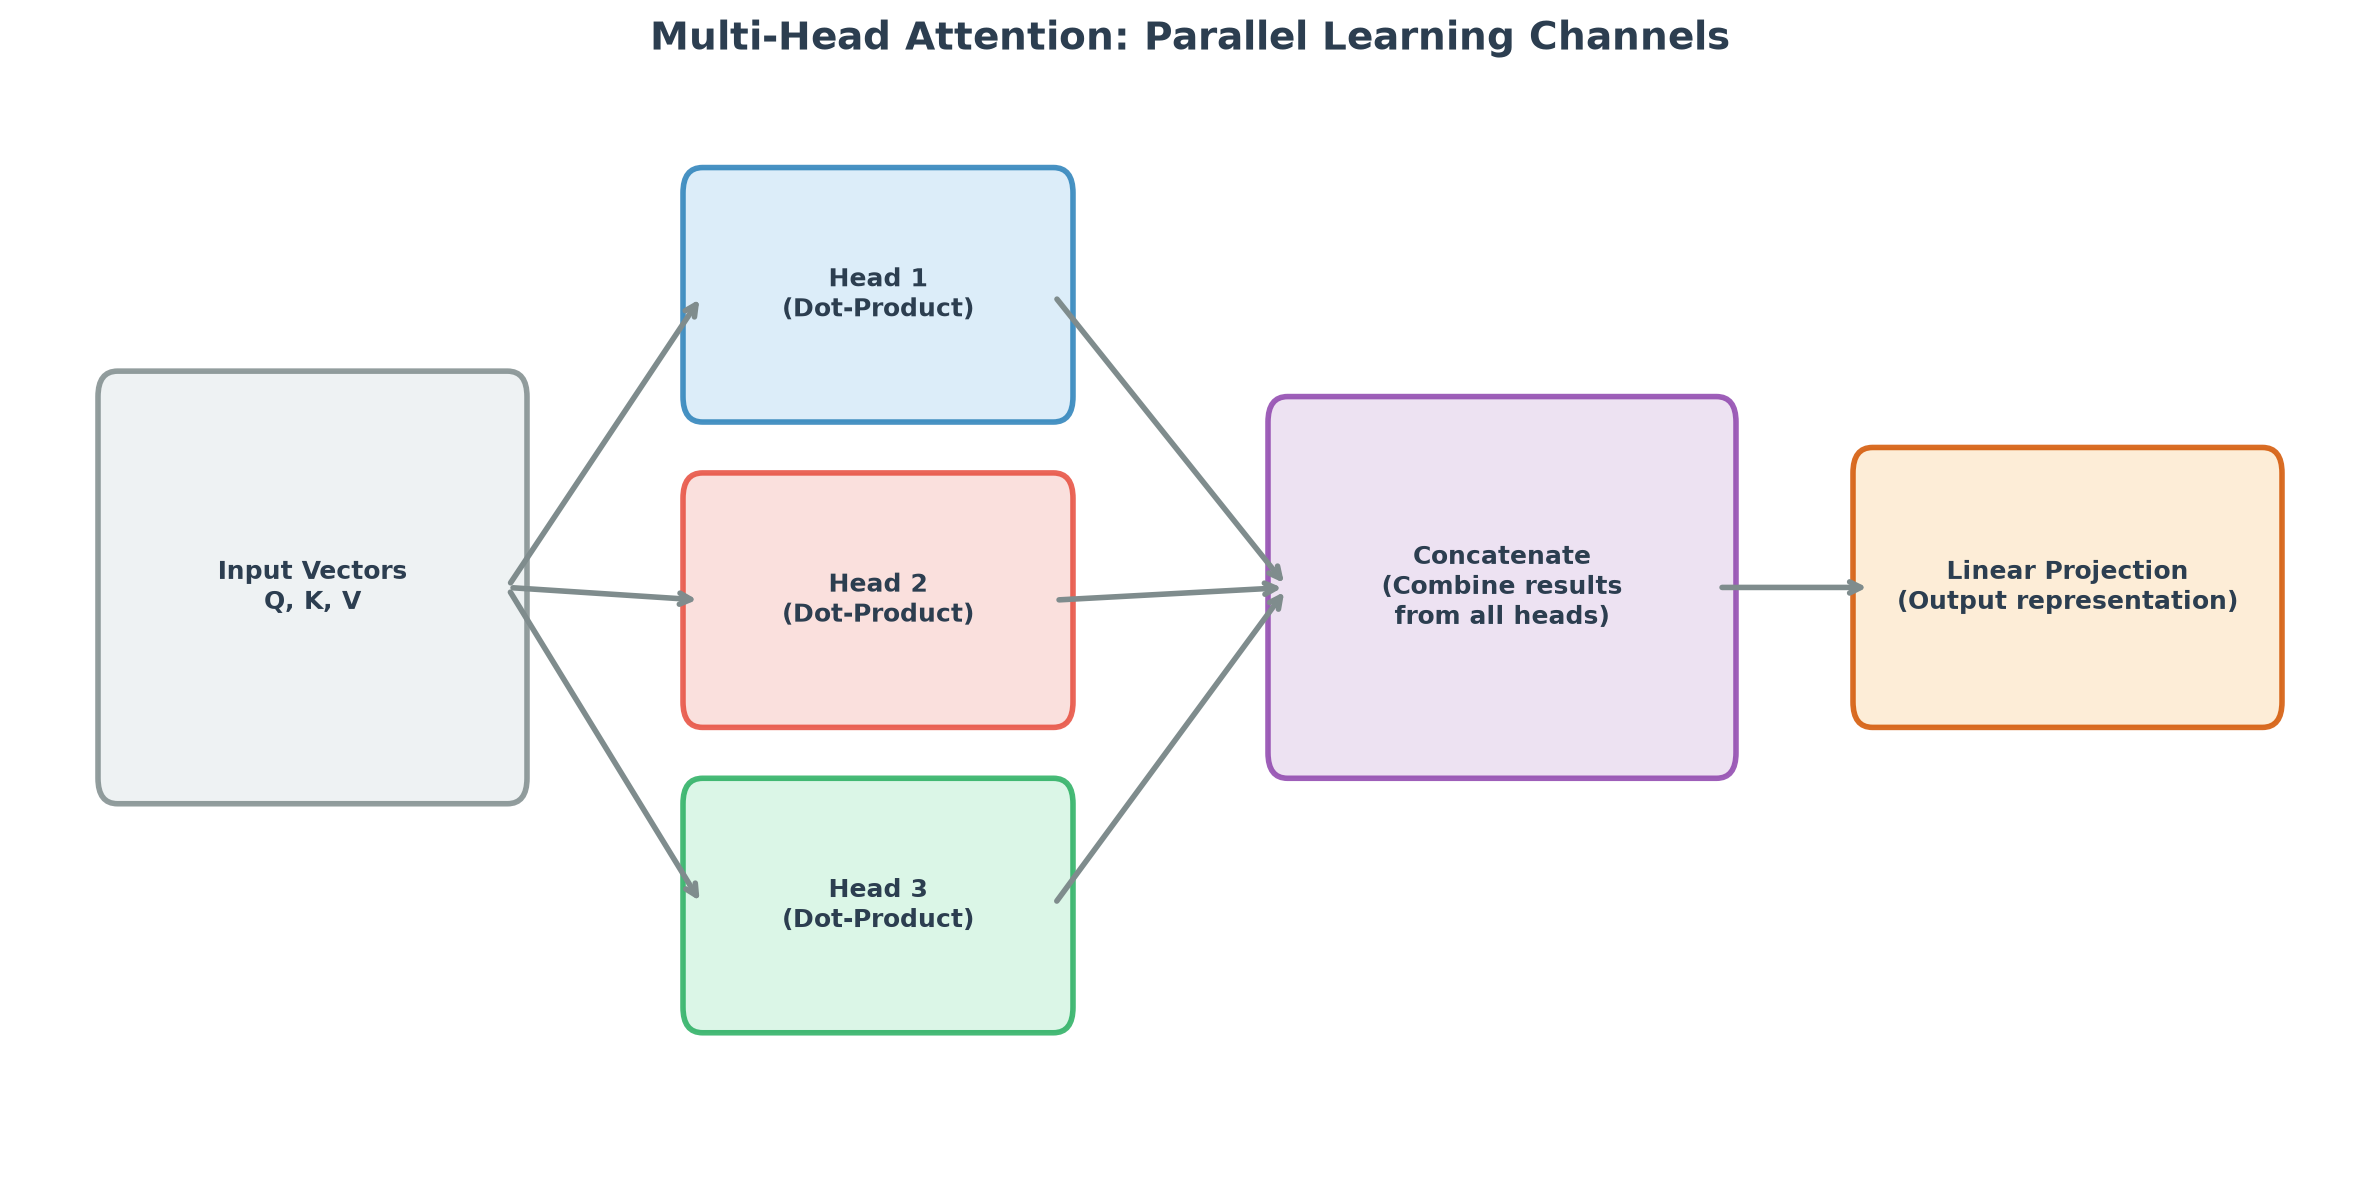

This division allows the model to learn multiple relationship structures simultaneously (e.g., one head focuses on subject-verb syntax relationships, while another focuses on semantic pronoun resolutions).

---

### 4. Causal Masking (Masked Attention)
During training, the decoder receives the entire target sentence. To prevent self-attention from attending to words that occur in the future, we apply a **Causal Mask**.

This mask replaces future scores with negative infinity ($-\infty$) before passing them to the Softmax function, converting future weights to exactly $0.0$.

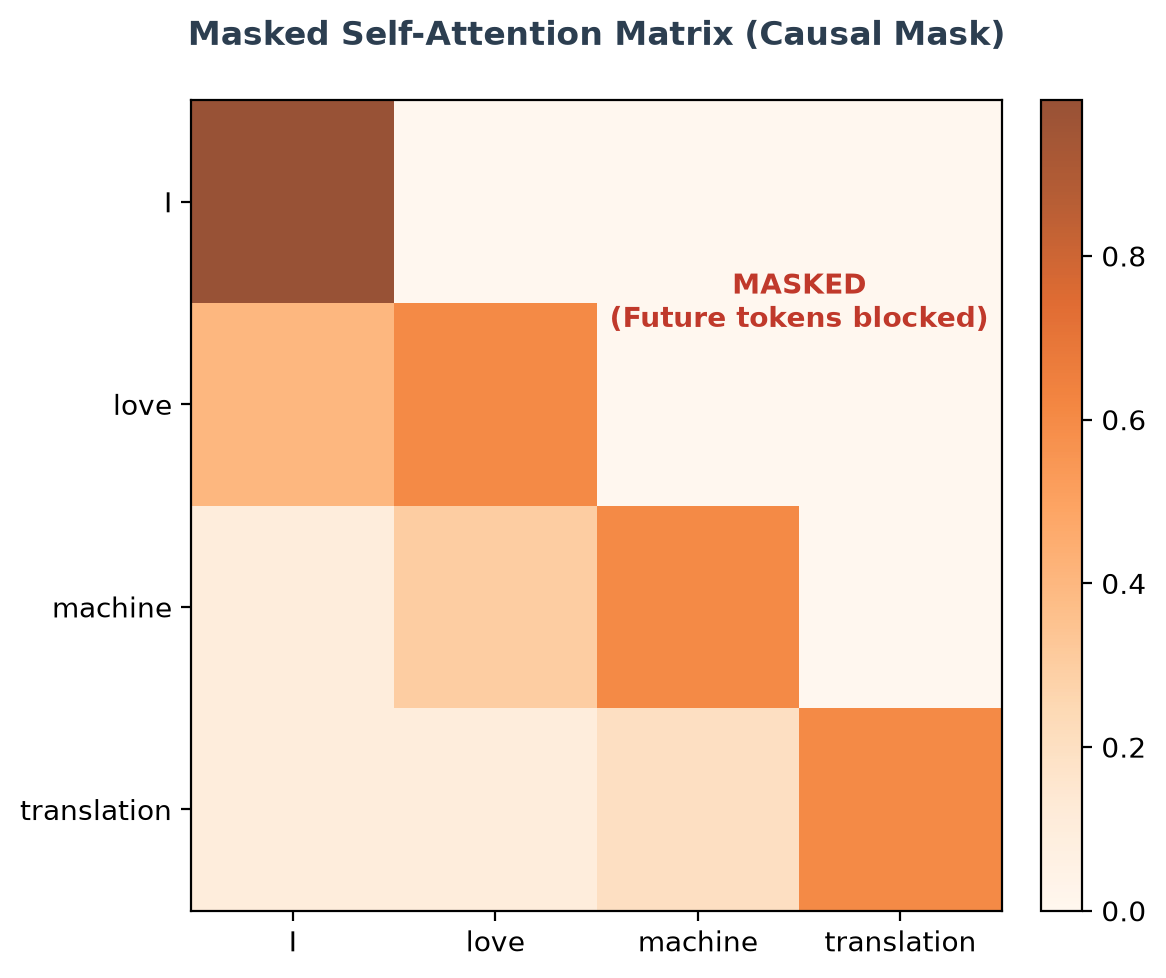

---

### 5. Residual Connections & Layer Normalization
To support deep neural stacks (typically 6 layers deep, up to hundreds in modern LLMs) without vanishing or exploding gradients, the Transformer utilizes **Residual Connections** and **Layer Normalization**.

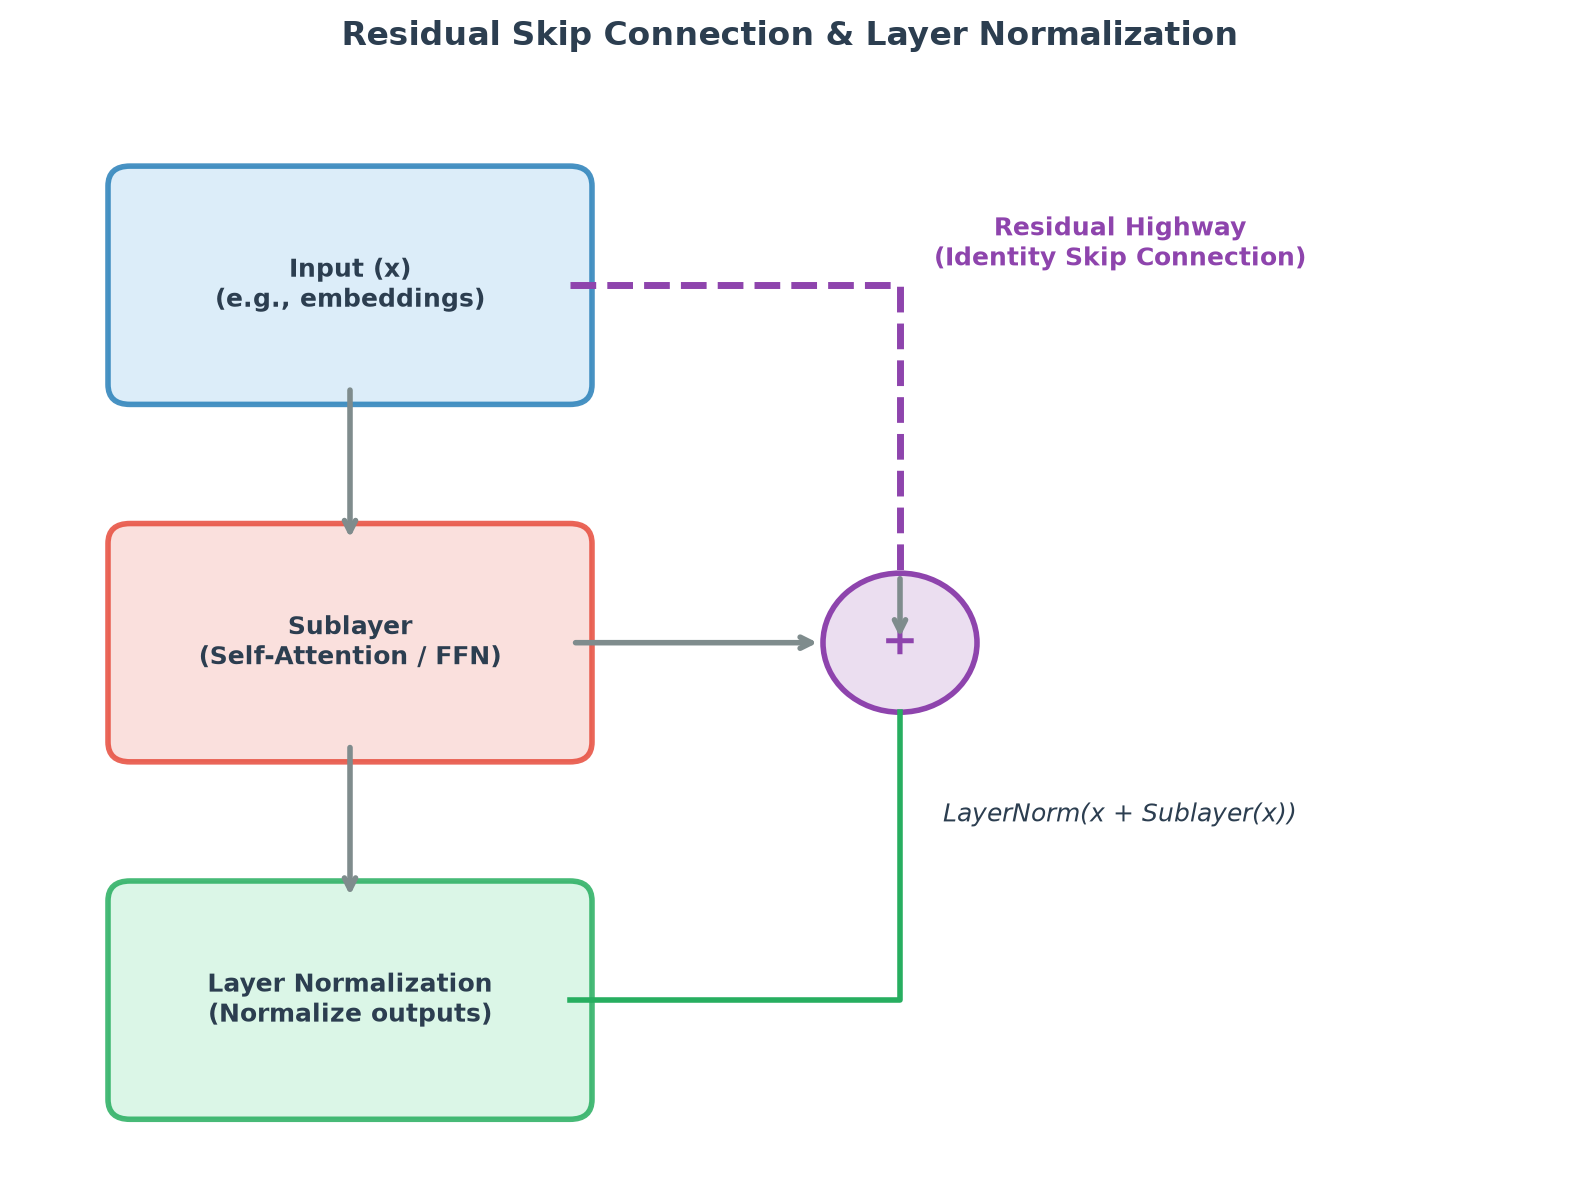
